# Animal 10 Classification


Dataset: https://www.kaggle.com/datasets/alessiocorrado99/animals10?resource=download&select=raw-img

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import glob as glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import  GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# Set up TensorFlow to use the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(gpus[0], True)

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
!kaggle datasets download -d alessiocorrado99/animals10
!unzip /content/animals10.zip

In [ ]:
dataset='/content/raw-img'
# Get the list of Class names and translate them
class_names=sorted(os.listdir(dataset))
class_mapping = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante':'elephant','farfalla': 'butterfly',
    'gallina': 'chicken', 'gatto': 'cat', 'mucca': 'cow',
    'pecora': 'sheep', 'scoiattolo': 'squirrel', 'cavallo': 'horse', 'ragno': 'spider'
}
translated_class_names = [class_mapping[class_name] for class_name in class_names]
number_of_classes= sorted(os.listdir(dataset))
# sequentaially print class names with number of classes
print("Class Names:")
print(translated_class_names)
num_classes = len(class_names)
print("Number of Classes:", num_classes)

Class Names:
['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Number of Classes: 10


set up data segmentation

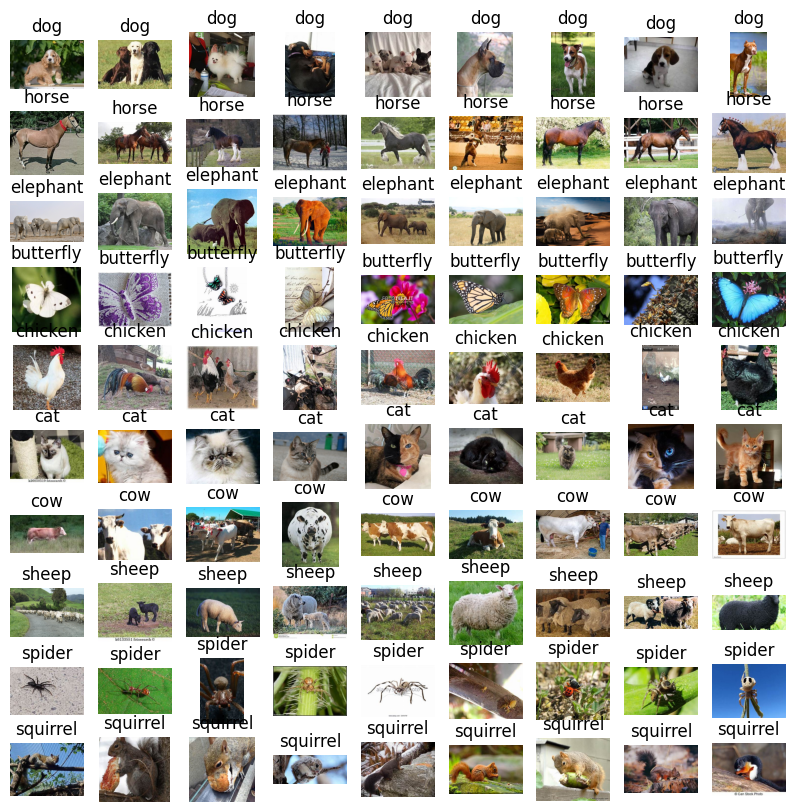

In [ ]:
# Function to show some samples with class names
def show_samples(data_path, class_names, num_samples=9):
    plt.figure(figsize=(10, 10))
    for i, class_name in enumerate(class_names):
        image_files = os.listdir(os.path.join(dataset, class_name))
        sample_files = random.sample(image_files, min(num_samples, len(image_files)))
        for j, file_name in enumerate(sample_files):
            plt.subplot(len(class_names), num_samples, i * num_samples + j + 1)
            image = plt.imread(os.path.join(dataset, class_name, file_name))
            plt.imshow(image)
            plt.title(translated_class_names[i])
            plt.axis('off')
    plt.show()

# Usage:
show_samples(dataset, class_names)

split into train test and validataion dataset

In [ ]:
# Function to split dataset into train, test, and validation sets
def split_dataset(data_path, test_size=0.2, validation_size=0.2):
    image_files = []
    labels = []
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(data_path, class_name)
        class_files = os.listdir(class_path)
        image_files += [os.path.join(class_path, file) for file in class_files]
        labels += [i] * len(class_files)
    X_train, X_test, y_train, y_test = train_test_split(image_files, labels, test_size=test_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=validation_size, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Split dataset into train, validation, and test sets
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(dataset)


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

set image data generator for training and validation

In [ ]:
# Create DataFrame for train, validation, and test sets
train_df = pd.DataFrame({'filename': X_train, 'class': y_train})
val_df = pd.DataFrame({'filename': X_val, 'class': y_val})
test_df = pd.DataFrame({'filename': X_test, 'class': y_test})

# Create image data generators
train_generator = train_datagen.flow_from_dataframe(dataframe=train_df, x_col='filename', y_col='class',
                                                    target_size=(256, 256), batch_size=32, class_mode='raw')
val_generator = train_datagen.flow_from_dataframe(dataframe=val_df, x_col='filename', y_col='class',
                                                  target_size=(256, 256), batch_size=32, class_mode='raw')
test_generator = train_datagen.flow_from_dataframe(dataframe=test_df, x_col='filename', y_col='class',
                                                   target_size=(256, 256), batch_size=1, class_mode='raw', shuffle=False)

Found 16754 validated image filenames.
Found 4189 validated image filenames.
Found 5236 validated image filenames.


create a Convolutional Neural Network model

In [ ]:
def define_resnet_model(input_shape, num_classes):
    base_model = ResNet152V2(include_top=False, input_shape=input_shape, weights='imagenet')
    for layer in base_model.layers:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

# Define the input shape and number of classes
input_shape = (256, 256, 3)
num_classes = 10  # Update this with your number of classes

# Define the ResNet152V2 model
model = define_resnet_model(input_shape, num_classes)

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print the model summary
model.summary()

234545216/234545216 [==============================] - 2s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 262, 262, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 128, 128, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 130, 130, 64)         0         ['conv1_conv[0][0]']          
                           

In [ ]:
# Train the model (assuming you have train and validation data generators)
cbs = [EarlyStopping(patience=3, restore_best_weights=True), ModelCheckpoint("model.h5", save_best_only=True)]
history = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=cbs)

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Epoch 1/10
  7/524 [..............................] - ETA: 3:22:13 - loss: 1.6688 - accuracy: 0.5268

KeyboardInterrupt: 

In [ ]:
def test_model(model, test_generator, class_names, num_samples=1):
    # Get a batch of random samples from the test generator
    test_batch = next(test_generator)
    test_images, test_labels = test_batch

    # Make predictions for the test batch
    predictions = model.predict(test_images)
    predicted_classes = np.argmax(predictions, axis=1)

    # Display the test images with their predicted classes
    plt.figure(figsize=(15, 8))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(test_images[0])  # Accessing the first (and only) image in the batch
        plt.title(f'Predicted: {class_names[predicted_classes[0]]}\nTrue: {class_names[test_labels[0]]}')
        plt.axis('off')
    plt.show()

# Test the model using random samples from the test generator
test_model(model, test_generator, class_names)

In [ ]:

def evaluate_model(model, data_generator):
    # Generate predictions for the dataset
    predictions = model.predict(data_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.array(data_generator.labels)

    # Compute accuracy score
    accuracy = accuracy_score(true_classes, predicted_classes)

    # Compute F1 score
    f1 = f1_score(true_classes, predicted_classes, average='weighted')

    return accuracy, f1

# Evaluate the model on the test generator
test_accuracy, test_f1 = evaluate_model(model, test_generator)
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

AttributeError: 'str' object has no attribute 'predict'

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(true_labels, predicted_labels, class_names):
    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

# Get true and predicted labels for the validation dataset
true_labels = []
predicted_labels = []

num_images= 1000
test_generator = (next(test_generator) for _ in range(num_images))

for batch in test_generator:
    images, labels = batch
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_labels.extend(labels)
    predicted_labels.extend(predicted_classes)

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Plot confusion matrix
plot_confusion_matrix(true_labels, predicted_labels, class_names)


Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 0s 43ms/step
